In [7]:
import featuregraph_smoothing_core as fg

In [8]:
bidmc = fg.datasets.bidmc(subject=1)
# tep = fg.datasets.eastman(fault_number=2, simulation_run=1,)
# # tep = fg.datasets.eastman(dataset='faultfree_training')
# hr = fg.datasets.wearable_hr(subject="S01")

In [9]:
bidmc

,time,respiration,ppg,ecg_v,ecg_avr,ecg_ii,subject
0,0.000,0.35386,0.43597,0.52549,0.30392,0.72549,1
1,0.008,0.35679,0.43206,0.51961,0.33529,0.67059,1
2,0.016,0.35875,0.42815,0.51569,0.37451,0.60980,1
3,0.024,0.36168,0.42424,0.50588,0.41961,0.55098,1
4,0.032,0.36364,0.42131,0.50980,0.44902,0.50000,1
...,...,...,...,...,...,...,...
59996,479.970,0.15640,0.40567,0.50000,0.51961,0.40000,1
59997,479.980,0.15152,0.40371,0.50588,0.52941,0.39412,1
59998,479.980,0.14663,0.40176,0.50000,0.53529,0.38431,1
59999,479.990,0.14174,0.40176,0.50000,0.53922,0.38039,1


In [10]:
hr = fg.datasets.wearable_hr(subject="S01")

In [11]:
hr

,seconds_from_start,timestamp_utc,heart_rate_bpm,subject
0,0.0,1.361383e+09,59.00,S01
1,1.0,1.361383e+09,79.50,S01
2,2.0,1.361383e+09,108.67,S01
3,3.0,1.361383e+09,101.25,S01
4,4.0,1.361383e+09,94.80,S01
...,...,...,...,...
2210,2210.0,1.361385e+09,54.67,S01
2211,2211.0,1.361385e+09,54.70,S01
2212,2212.0,1.361385e+09,54.75,S01
2213,2213.0,1.361385e+09,54.82,S01


(<Figure size 1600x440 with 2 Axes>,
 array([<Axes: ylabel='seconds_from_start'>,
        <Axes: xlabel='Time', ylabel='heart_rate_bpm'>], dtype=object))

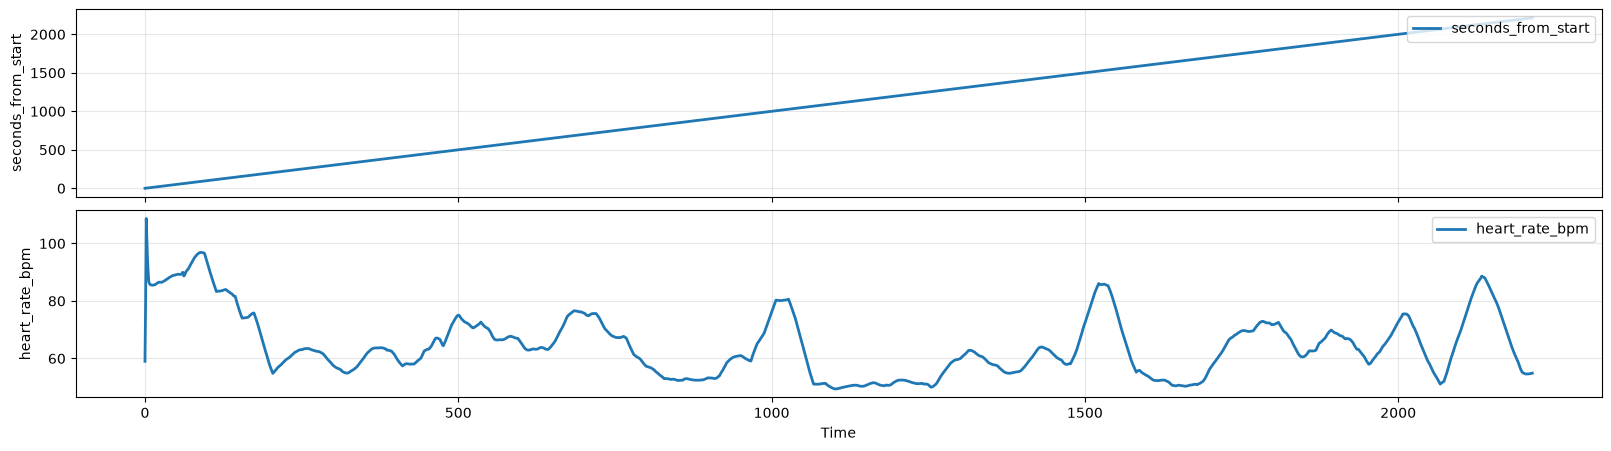

In [13]:
fg.plot(hr, [
                ['seconds_from_start'],
                ['heart_rate_bpm'],
            ]
)

In [14]:
hr["seconds_from_start"].diff().describe()

count    2214.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: seconds_from_start, dtype: float64

Text(0, 0.5, 'autocorrelation')

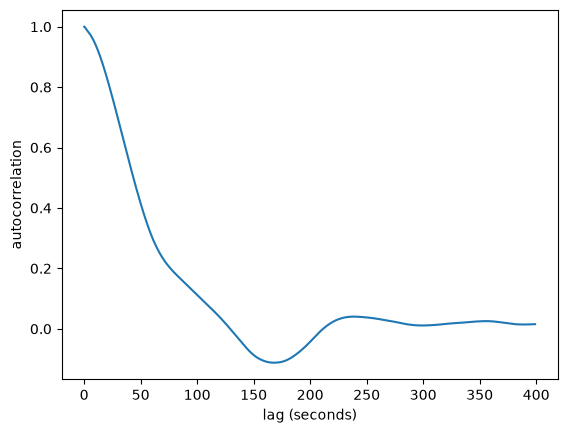

In [15]:
import numpy as np

x = hr["heart_rate_bpm"].to_numpy()
x = x - x.mean()
acf = np.correlate(x, x, mode="full")[len(x)-1:]
acf = acf / acf[0]

# look for the first real peak after the initial decay, not just lag 0
import matplotlib.pyplot as plt
plt.plot(acf[:400])
plt.xlabel("lag (seconds)")
plt.ylabel("autocorrelation")

In [16]:
temp = fg.datasets.wearable_temp(subject="S01")

In [17]:
temp

,seconds_from_start,timestamp_utc,temp_celsius,subject
0,0.00,1.361383e+09,32.09,S01
1,0.25,1.361383e+09,32.09,S01
2,0.50,1.361383e+09,32.09,S01
3,0.75,1.361383e+09,32.09,S01
4,1.00,1.361383e+09,32.09,S01
...,...,...,...,...
8891,2222.75,1.361385e+09,33.31,S01
8892,2223.00,1.361385e+09,33.34,S01
8893,2223.25,1.361385e+09,33.34,S01
8894,2223.50,1.361385e+09,33.34,S01


(<Figure size 1600x440 with 2 Axes>,
 array([<Axes: ylabel='seconds_from_start'>,
        <Axes: xlabel='Time', ylabel='heart_rate_bpm'>], dtype=object))

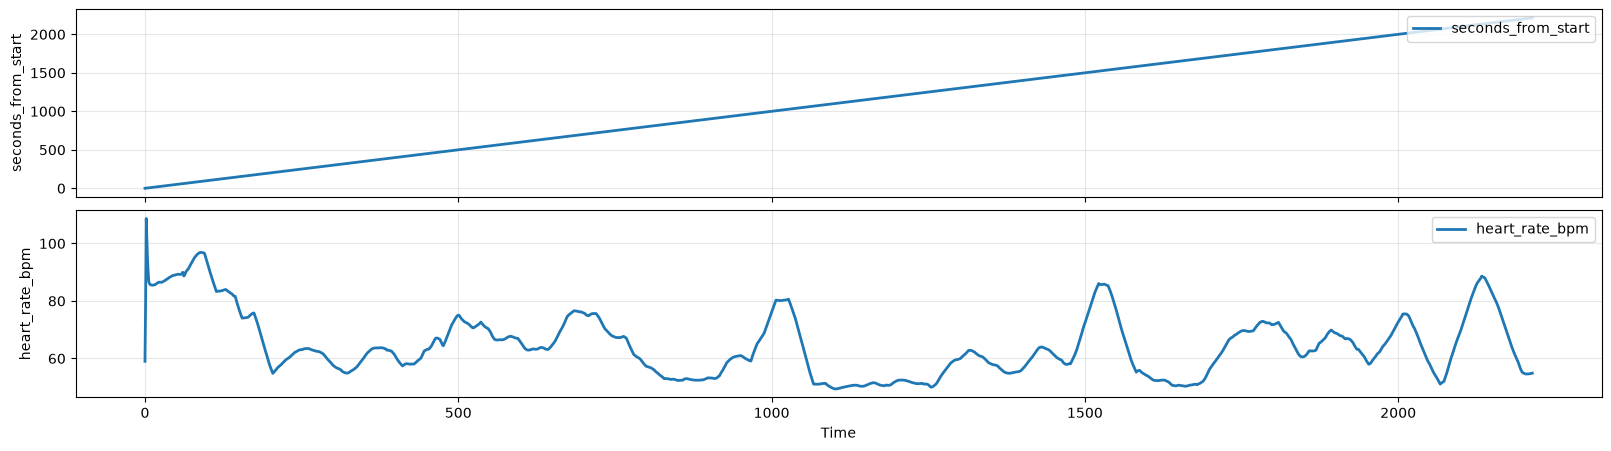

In [18]:
fg.plot(hr, [
                ['seconds_from_start'],
                ['heart_rate_bpm'],
            ]
)

22 objects


,subject,heart_rate_bpm_trough_event_id,start_index,rising_duration,falling_duration,peak_index,trough_index,max_raw_signal,max_smooth_signal,min_raw_signal,...,is_complete,duration,period,amplitude_raw,amplitude_smooth,raw_rising_mean_rate,raw_falling_mean_rate,smooth_rising_mean_rate,smooth_falling_mean_rate,temporal_symmetry
0,S01,0,NaN,0,0,NaN,NaN,108.67,86.16650,59.00,...,False,0,NaN,24.835,0.000000,NaN,NaN,NaN,NaN,NaN
1,S01,1,21.0,69,76,90.0,21.0,96.87,96.07150,74.03,...,True,145,NaN,11.420,10.803750,0.331014,0.300526,0.313152,0.284309,0.951724
2,S01,2,166.0,2,42,168.0,166.0,75.80,74.48075,54.80,...,True,44,78.0,10.500,8.773000,10.500000,0.500000,8.773000,0.417762,0.090909
3,S01,3,210.0,49,65,259.0,210.0,63.43,63.17875,54.92,...,True,114,91.0,4.255,3.862500,0.173673,0.130923,0.157653,0.118846,0.859649
4,S01,4,324.0,51,47,375.0,324.0,63.73,63.59750,54.90,...,True,98,116.0,4.415,4.070625,0.173137,0.187872,0.159632,0.173218,0.959184
